In [73]:
import collections
from IPython import display
import matplotlib.pyplot as plt

import numpy as np
import torch
import itertools as itr
from torch import nn
from common.ffn.ffn_relu import ParametricReLUNet
from common.coeff_calc.coeff_calc_ntk import NTKSimulator
from sklearn.metrics import mean_squared_error

from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from util import *
import logging

In [74]:
logging.basicConfig(filename="log_twosteps_minst.log",
                level=logging.INFO,
                format='%(levelname)s: %(asctime)s %(message)s',
                datefmt='%m/%d/%Y %I:%M:%S')

In [75]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = MNIST(root='./', train=True, download=True, transform=image_transform)
test_dataset = MNIST(root='./', train=False, download=True, transform=image_transform)

In [76]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

##### CONSTANTS

In [77]:
INPUT_DIM = 28 * 28
OUTPUT_DIM = 10  # num classes
INPUT_WIDTH, HIDDEN_WIDTH = 250, 100 #100, 50 # #500, 200
NUM_EPOCH = 100

#lw = 7.5 - for BATCH_SIZE = 32
lb, lw = 1e-2, 7.5 #1e-2,1,1 #1e-2, 1e-2, 1
#lambdas as from (8.5)
lw_input, lw_hidden, lw_output = lw/INPUT_DIM, lw/INPUT_WIDTH, lw/HIDDEN_WIDTH

In [78]:
class MNISTReLU(ParametricReLUNet):
    def __init__(self, input_dim, output_dim):
        super().__init__(n0=input_dim,nk=0,nl=output_dim,l=0, bias_on=True)

        self.input_fc = nn.Linear(input_dim, INPUT_WIDTH)
        self.hidden_fc = nn.Linear(INPUT_WIDTH, HIDDEN_WIDTH)
        self.output_fc = nn.Linear(HIDDEN_WIDTH, output_dim)

    def forward_(self, x):
        return self.forward(x)

    def forward(self, x):
        #x = [batch size, height, width]
        #x = [batch size, height * width]
        h_1 = self.PReLU(self.input_fc(x))
        #h_1 = [batch size, INPUT_WIDTH]
        h_2 = self.PReLU(self.hidden_fc(h_1))
        #h_2 = [batch size, HIDDEN_WIDTH]
        y_pred = self.output_fc(h_2)
        #y_pred = [batch size, output dim]
        return y_pred
    
    def init_weights(self, cb=0.0, cw=1.0):
        if self.get_log_level() == "debug":
            print("FeedForwardNet weights initialisation with cb={}, cw={}".format(cb, cw))

        #Weight initialisation as in 2.19, 2.20
        self.cb, self.cw = cb, cw
        self.init_linear_weights(self.input_fc, self.bias_on, cb, cw/self.input_fc.in_features)
        self.init_linear_weights(self.hidden_fc, self.bias_on, cb, cw/self.hidden_fc.in_features)
        self.init_linear_weights(self.output_fc, self.bias_on, cb, cw/self.output_fc.in_features)

    def grad_zero(self):
        self.input_fc.weight.grad.zero_()
        self.input_fc.bias.grad.zero_()
        self.hidden_fc.weight.grad.zero_()
        self.hidden_fc.bias.grad.zero_()
        self.output_fc.weight.grad.zero_()
        self.output_fc.bias.grad.zero_()

##### UTILS

In [79]:
def labels_to_logits(labels):
    batch_size = labels.shape[0]
    zz = np.full((OUTPUT_DIM, batch_size), -3.0)
    for batch_num in range(batch_size):
        zz[labels[batch_num], batch_num] = 3

    #logging.debug("Logits for iteration {}: {}".format(iteration_num, np.transpose(yy)))
    return zz

def visualise():
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    axes[0].set_title('Loss (MSE)')
    axes[0].plot(HISTORY_PARAMS['train_loss'], label='Train Loss')
    axes[0].plot(HISTORY_PARAMS['test_loss'], label='Test Loss')
    axes[0].grid()
    axes[0].legend(fontsize=20)
    
    axes[1].set_title('Accuracy')
    axes[1].plot(HISTORY_PARAMS['train_accuracy'], label='Train Accuracy')
    axes[1].plot(HISTORY_PARAMS['test_accuracy'], label='Test Accuracy')
    axes[1].grid()
    axes[1].legend(fontsize=20)
    
    plt.show()

HISTORY_PARAMS = collections.defaultdict(list)

##### FFN initialisation

In [80]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

testNet = MNISTReLU(INPUT_DIM, OUTPUT_DIM)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
testNet.init_weights(cb, cw)


FeedForwardNet created with n0=784, nk=0, nl=10, l=0, bias_on=True


##### LOOP STARTS HERE

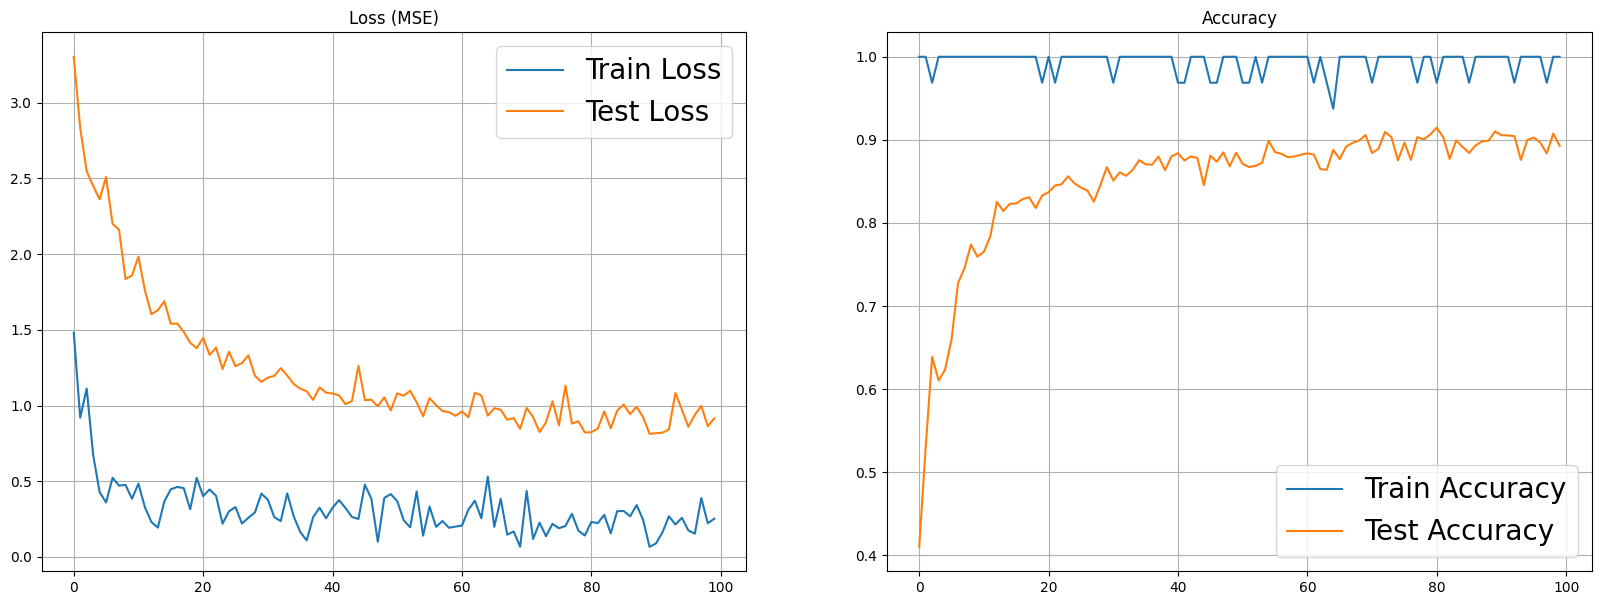

In [81]:
def do_step0(delta):
    with torch.no_grad():
        testNet.input_fc.weight += torch.from_numpy(delta_weight_00) * delta
        testNet.input_fc.bias += torch.from_numpy(delta_bias_00) * delta
        testNet.hidden_fc.weight += torch.from_numpy(delta_weight_01) * delta
        testNet.hidden_fc.bias += torch.from_numpy(delta_bias_01) * delta
        testNet.output_fc.weight += torch.from_numpy(delta_weight_02) * delta
        testNet.output_fc.bias += torch.from_numpy(delta_bias_02) * delta
        logits_step0 = testNet.forward_(xx)
        prediction_step0 = logits_step0.argmax(dim=-1)
        zz0 = np.transpose(logits_step0.detach().numpy())

    accuracy_step0 = calculate_accuracy(prediction_step0, labels)
    mse_step0 = mean_squared_error(yy, zz0)
    return accuracy_step0, mse_step0, zz0

def do_step1(delta):
    with torch.no_grad():
        testNet.input_fc.weight += torch.from_numpy(delta_weight_10) * delta
        testNet.input_fc.bias += torch.from_numpy(delta_bias_10) * delta
        testNet.hidden_fc.weight += torch.from_numpy(delta_weight_11) * delta
        testNet.hidden_fc.bias += torch.from_numpy(delta_bias_11) * delta
        testNet.output_fc.weight += torch.from_numpy(delta_weight_12) * delta
        testNet.output_fc.bias += torch.from_numpy(delta_bias_12) * delta
        logits_step1 = testNet.forward_(xx)
        prediction_step1 = logits_step1.argmax(dim=-1)
        zz1 = np.transpose(logits_step1.detach().numpy())

    accuracy_step1 = calculate_accuracy(prediction_step1, labels)
    mse_step1 = mean_squared_error(yy, zz1)
    return accuracy_step1, mse_step1, zz1

iteration_num, coeff_delta = 0, 0.1

while iteration_num < NUM_EPOCH:
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter()

    images, labels = next(iter(train_dataloader))
    yy = labels_to_logits(labels) #true logits ∈ [-3, 3]
    #images = [batch_size, height, width]
    batch_size = images.shape[0]
    xx = images.view(batch_size, -1)
    testNet.grad_zero
    logits = testNet.forward_(xx)
    zz = np.transpose(logits.detach().numpy()) #obtained logits

    prediction_beforesteps = logits.argmax(dim=-1)
    accuracy_beforesteps = calculate_accuracy(prediction_beforesteps, labels)
    mse_beforesteps = mean_squared_error(yy, zz)    
    logging.info("Before steps iter {}: accuracy={}, MSE={}".format(iteration_num, accuracy_beforesteps, mse_beforesteps))

    print("#Calculating NTK for step 0")
    input_dweight = np.zeros((OUTPUT_DIM, BATCH_SIZE, INPUT_WIDTH, INPUT_DIM))
    input_dbias = np.zeros((OUTPUT_DIM, BATCH_SIZE, INPUT_WIDTH))
    hidden_dweight = np.zeros((OUTPUT_DIM, BATCH_SIZE, HIDDEN_WIDTH, INPUT_WIDTH))
    hidden_dbias = np.zeros((OUTPUT_DIM, BATCH_SIZE, HIDDEN_WIDTH))
    output_dweight = np.zeros((OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM, HIDDEN_WIDTH))
    output_dbias = np.zeros((OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM))

    for kk, alpha in itr.product(range(OUTPUT_DIM), range(BATCH_SIZE)):
        df = torch.autograd.grad(logits[alpha,kk], (testNet.input_fc.weight, testNet.input_fc.bias\
                                        , testNet.hidden_fc.weight, testNet.hidden_fc.bias\
                                        , testNet.output_fc.weight, testNet.output_fc.bias)\
            , retain_graph=True, create_graph=True, allow_unused=True)
        input_dweight[kk, alpha] = df[0].detach().numpy()
        input_dbias[kk, alpha] = df[1].detach().numpy()
        hidden_dweight[kk, alpha] = df[2].detach().numpy()
        hidden_dbias[kk, alpha] = df[3].detach().numpy()
        output_dweight[kk, alpha] = df[4].detach().numpy()
        output_dbias[kk, alpha] = df[5].detach().numpy()

    print("##Calculating NTK by (8.4)")
    HL = np.zeros((OUTPUT_DIM, OUTPUT_DIM, BATCH_SIZE, BATCH_SIZE))
    for kk1, kk2, alpha1, alpha2 in itr.product(range(OUTPUT_DIM), range(OUTPUT_DIM)\
                                                , range(BATCH_SIZE), range(BATCH_SIZE)):
        if HL[kk1, kk2, alpha1, alpha2] == 0 or HL[kk2, kk1, alpha2, alpha1] == 0:
            val = lb * np.dot(input_dbias[kk1, alpha1], input_dbias[kk2, alpha2])
            val += lw_input * np.sum(np.multiply(input_dweight[kk1, alpha1], input_dweight[kk2, alpha2]))
            val += lb * np.dot(hidden_dbias[kk1, alpha1], hidden_dbias[kk2, alpha2])
            val += lw_hidden * np.sum(np.multiply(hidden_dweight[kk1, alpha1], hidden_dweight[kk2, alpha2]))
            val += lb * np.dot(output_dbias[kk1, alpha1], output_dbias[kk2, alpha2])
            val += lw_output * np.sum(np.multiply(output_dweight[kk1, alpha1], output_dweight[kk2, alpha2]))
            HL[kk1, kk2, alpha1, alpha2] = HL[kk2, kk1, alpha2, alpha1] = val

    print("##Calculating average and inverted")
    HL_avg = np.zeros((BATCH_SIZE, BATCH_SIZE))
    HL_delta = np.copy(HL)

    for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
        H_avg = np.average([HL[num, num, alpha1, alpha2] for num in np.arange(OUTPUT_DIM)])
        HL_avg[alpha1, alpha2] = H_avg
        for num in np.arange(OUTPUT_DIM):
            HL_delta[num, num, alpha1, alpha2] = HL[num, num, alpha1, alpha2] - H_avg

    HL_avg_top = np.linalg.inv(HL_avg)

    print("#Calculating Newton tensor by (∞.71), weights update by (∞.68) and checking accuracy")
    term0 = np.zeros((OUTPUT_DIM, OUTPUT_DIM, BATCH_SIZE, BATCH_SIZE))
    for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
        for num in range(OUTPUT_DIM):
            term0[num, num, alpha1, alpha2] = HL_avg_top[alpha1, alpha2]

    term1a = np.tensordot(np.tensordot(HL_avg_top, HL_delta, axes=((1),(2))), HL_avg_top, axes=((3),(0)))
    term1 = np.transpose(term1a, (1,2,0,3))

    term2a = term1a #np.tensordot(HL_avg_top, HL_delta, axes=((1),(2)))
    term2b = np.tensordot(np.tensordot(term2a, HL_delta, axes=((2,3),(0,2))), HL_avg_top, axes=((3),(0)))
    term2 = np.transpose(term2b, (1,2,0,3))

    eta_kappa = term0 - term1 + term2; #(∞.71)

    term = -1*np.tensordot(eta_kappa, (zz - yy), axes=((1,3),(0,1)))
    delta_weight_00 = np.tensordot(term, input_dweight, axes=((0,1),(0,1))) * lw_input #(∞.68)
    delta_bias_00 = np.tensordot(term, input_dbias, axes=((0,1),(0,1))) * lb #(∞.68)
    delta_weight_01 = np.tensordot(term, hidden_dweight, axes=((0,1),(0,1))) * lw_hidden #(∞.68)
    delta_bias_01 = np.tensordot(term, hidden_dbias, axes=((0,1),(0,1))) * lb #(∞.68)
    delta_weight_02 = np.tensordot(term, output_dweight, axes=((0,1),(0,1))) * lw_output #(∞.68)
    delta_bias_02 = np.tensordot(term, output_dbias, axes=((0,1),(0,1))) * lb #(∞.68)

    accuracy_prev, mse_prev = accuracy_beforesteps, mse_beforesteps
    coeff_abs = 0.0
    while (round(coeff_abs, 1)) < 1.0:
        coeff_abs += coeff_delta
        accuracy_step0, mse_step0, _ = do_step0(coeff_delta)
        if (accuracy_step0 < accuracy_prev or (accuracy_step0 > 0.5 and mse_step0 >= mse_prev)):
            coeff_abs -= coeff_delta
            accuracy_step0, mse_step0, _ = do_step0(-coeff_delta)
            break;
            
        accuracy_prev, mse_prev = accuracy_step0, mse_step0

    logging.info("After step0 iter {}, coeff_abs {}: accuracy={}, MSE={}"\
                 .format(iteration_num, coeff_abs, accuracy_step0, mse_step0))
    
    print("##Calculating NTK for step 1")
    testNet.grad_zero
    logits0 = testNet.forward_(xx)
    zz0 = np.transpose(logits0.detach().numpy())

    print("##Calculating derivatives")
    input_dweight0 = np.zeros((OUTPUT_DIM, BATCH_SIZE, INPUT_WIDTH, INPUT_DIM))
    input_dbias0 = np.zeros((OUTPUT_DIM, BATCH_SIZE, INPUT_WIDTH))
    hidden_dweight0 = np.zeros((OUTPUT_DIM, BATCH_SIZE, HIDDEN_WIDTH, INPUT_WIDTH))
    hidden_dbias0 = np.zeros((OUTPUT_DIM, BATCH_SIZE, HIDDEN_WIDTH))
    output_dweight0 = np.zeros((OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM, HIDDEN_WIDTH))
    output_dbias0 = np.zeros((OUTPUT_DIM, BATCH_SIZE, OUTPUT_DIM))

    for kk, alpha in itr.product(range(OUTPUT_DIM), range(BATCH_SIZE)):
        df = torch.autograd.grad(logits0[alpha,kk], (testNet.input_fc.weight, testNet.input_fc.bias\
                                        , testNet.hidden_fc.weight, testNet.hidden_fc.bias\
                                        , testNet.output_fc.weight, testNet.output_fc.bias)\
            , retain_graph=True, create_graph=True, allow_unused=True)
        input_dweight0[kk, alpha] = df[0].detach().numpy()
        input_dbias0[kk, alpha] = df[1].detach().numpy()
        hidden_dweight0[kk, alpha] = df[2].detach().numpy()
        hidden_dbias0[kk, alpha] = df[3].detach().numpy()
        output_dweight0[kk, alpha] = df[4].detach().numpy()
        output_dbias0[kk, alpha] = df[5].detach().numpy()

    print("##Calculating NTK by (8.4)")
    HL0 = np.zeros((OUTPUT_DIM, OUTPUT_DIM, BATCH_SIZE, BATCH_SIZE))
    for kk1, kk2, alpha1, alpha2 in itr.product(range(OUTPUT_DIM), range(OUTPUT_DIM)\
                                                , range(BATCH_SIZE), range(BATCH_SIZE)):
        if HL0[kk1, kk2, alpha1, alpha2] == 0 or HL0[kk2, kk1, alpha2, alpha1] == 0:    
            val0 = lb * np.dot(input_dbias0[kk1, alpha1], input_dbias0[kk2, alpha2])
            val0 += lw_input * np.sum(np.multiply(input_dweight0[kk1, alpha1], input_dweight0[kk2, alpha2]))
            val0 += lb * np.dot(hidden_dbias0[kk1, alpha1], hidden_dbias0[kk2, alpha2])
            val0 += lw_hidden * np.sum(np.multiply(hidden_dweight0[kk1, alpha1], hidden_dweight0[kk2, alpha2]))
            val0 += lb * np.dot(output_dbias0[kk1, alpha1], output_dbias0[kk2, alpha2])
            val0 += lw_output * np.sum(np.multiply(output_dweight0[kk1, alpha1], output_dweight0[kk2, alpha2]))
            HL0[kk1, kk2, alpha1, alpha2] = HL0[kk2, kk1, alpha2, alpha1] = val0

    print("##Calculating average and inverted")
    HL0_avg = np.zeros((BATCH_SIZE, BATCH_SIZE))
    #HL_delta = np.copy(HL)

    for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
        H0_avg = np.average([HL[num, num, alpha1, alpha2] for num in np.arange(OUTPUT_DIM)])
        HL0_avg[alpha1, alpha2] = H0_avg

    HL0_avg_top = np.linalg.inv(HL0_avg)

    print("##Small step calculation")
    term0 = -1*np.matmul((zz0 - yy), HL0_avg_top)
    delta_weight_10 = np.tensordot(term0, input_dweight0, axes=([0,1],[0,1])) * lw_input
    delta_bias_10 = np.tensordot(term0, input_dbias0, axes=([0,1],[0,1])) * lb
    delta_weight_11 = np.tensordot(term0, hidden_dweight0, axes=([0,1],[0,1])) * lw_hidden
    delta_bias_11 = np.tensordot(term0, hidden_dbias0, axes=([0,1],[0,1])) * lb
    delta_weight_12 = np.tensordot(term0, output_dweight0, axes=([0,1],[0,1])) * lw_output
    delta_bias_12 = np.tensordot(term0, output_dbias0, axes=([0,1],[0,1])) * lb
    #Step forward
    accuracy_prev, mse_prev = accuracy_step0, mse_step0
    #logging.info("Before step1 iter {}: accuracy_prev={}, mse_prev={}".format(iteration_num, accuracy_prev, mse_prev))    
    coeff_abs = 0.0
    while (round(coeff_abs, 1)) < 1.0:
        coeff_abs += coeff_delta
        accuracy_step1, mse_step1, _ = do_step1(coeff_delta)
        #logging.info("In step1 iter {}: accuracy_step1 ={}, accuracy_prev={}, mse_step1={}, mse_prev={}"\
        #             .format(iteration_num, accuracy_step1, accuracy_prev, mse_step1, mse_prev))
        if (accuracy_step1 < accuracy_prev or mse_step1 >= mse_prev):
            coeff_abs -= coeff_delta
            accuracy_step1, mse_step1, _ = do_step1(-coeff_delta)
            break;
            
        accuracy_prev, mse_prev = accuracy_step1, mse_step1

    logging.info("After step1 iter {}, coeff_abs {}: accuracy={}, MSE={}"\
                 .format(iteration_num, coeff_abs, accuracy_step1, mse_step1))
    
    # save average train loss and accuracy
    HISTORY_PARAMS['train_loss'].append(mse_step1)
    HISTORY_PARAMS['train_accuracy'].append(accuracy_step1)

    # testing loop
    for test_images, test_labels in test_dataloader:
        test_batch_size = test_images.shape[0]
        test_xx = test_images.view(test_batch_size, -1)
        with torch.no_grad():
            test_logits = testNet.forward_(test_xx)
            test_prediction = test_logits.argmax(dim=-1)

        test_loss_meter.update(mean_squared_error\
                               (np.transpose(test_logits.detach().numpy()), labels_to_logits(test_labels)))
        #zz0 = np.transpose(logits_step0.detach().numpy())
        test_accuracy_meter.update(calculate_accuracy(test_prediction, test_labels))
    # save average test accuracy loss and accuracy
    HISTORY_PARAMS['test_loss'].append(test_loss_meter.avg)
    HISTORY_PARAMS['test_accuracy'].append(test_accuracy_meter.avg)
    
    visualise()
    iteration_num += 1


In [82]:
print(test_accuracy_meter.avg, test_accuracy_meter.count)

0.8926717252396166 313
